# Function 3 Analysis - Week 5

This notebook updates the analysis for **Function 3** in Week 5. We now work with **14 datapoints**, including the Week 4 query `(0.35, 0.258, 0.465)` (≈−0.0461) and the earlier Week 3 exploratory miss `(0.95, 0.95, 0.858)`. With two weak exploratory moves, we pivot back toward exploitation; the current EI maximiser is near `(0.373, 0.465, 0.419)`.

**Function Description:** 
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format. Inputs remain standardised in [0,1]. The Week 3 point `(0.95, 0.95, 0.858)` returned **-0.0617** (negative), and Week 4’s `(0.35, 0.258, 0.465)` scored **≈-0.0461**—better but still below the best. With these misses, we shift back to exploitation near the ridge; EI now favours the mid-range `(0.373, 0.465, 0.419)` area.


In [5]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, Week 2, Week 3, and Week 4 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])
X_new_point_week_4 = np.array([[0.350000, 0.258000, 0.465000]])
y_new_point_week_4 = np.array([-0.046106142152997354])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.403500,0.382200,0.489400,-0.011751
1,0.492581,0.611593,0.340176,-0.034835
2,0.600097,0.725136,0.066089,-0.036378
3,0.350000,0.258000,0.465000,-0.046106
4,0.220549,0.297825,0.343555,-0.046947
5,0.134622,0.219917,0.458206,-0.048008
6,0.965995,0.861120,0.566829,-0.056758
7,0.950000,0.950000,0.858000,-0.061672
8,0.242114,0.644074,0.272433,-0.087963
9,0.170477,0.697032,0.149169,-0.094190


- **New point (Week 1):** The `(~0.40, ~0.38, ~0.49)` query produced the best output yet at -0.011751.
- **New point (Week 2):** The `(0.50, 0.50, 0.65)` exploratory query came back at about -0.096 (very average), hinting that simply increasing x3 in that region does not help.
- **New point (Week 3):** The `(0.95, 0.95, 0.858)` exploratory move was negative (**-0.0617**). Two exploratory jumps underperformed, so we pivot back to exploitation.
- **New point (Week 4):** `(0.35, 0.258, 0.465)` scored **≈-0.0461**—better than Weeks 2–3 but **still below the best (-0.0118)**. EI now favours the mid-range `(0.373, 0.465, 0.419)` neighbourhood.


## Bayesian optimisation (expected improvement)

We use **expected improvement (EI)** and now lean back toward exploitation after two weak exploratory steps. EI converts the GP posterior (mean `μ`, std `σ`) into the expected improvement over `y_best`, balancing probability and magnitude of gain:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
with **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ the normal CDF, and φ the normal PDF.

Because the Week 2 and Week 3 exploratory jumps were negative, we **lower ξ to 0.001** to prioritise exploitation near the known ridge while still allowing modest variance-driven moves.

Workflow:
1) Fit a 3D Matern GP on `[x1, x2, x3]` (13 observed points).  
2) Evaluate EI on a dense `[0,1]^3` grid with the smaller ξ and highlight the maximiser. The current EI top set (feasible, min-step applied) starts with `(0.373, 0.465, 0.419)` followed by `(0.396, 0.465, 0.419)` and nearby variants.

`candidate_df` lists the top EI locations; rerun after adding data to refresh the ranking and plots.


In [7]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-3, 10.0)) * Matern(length_scale=[0.1, 0.1, 0.1], length_scale_bounds=(0.1, 0.2), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-6))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)

# Evaluate a dense grid of candidates inside the [0, 1]^3 design space
grid_size = 40  # 40^3 = 64,000 points
grid_x1 = np.linspace(0.05, 0.95, grid_size)
grid_x2 = np.linspace(0.05, 0.95, grid_size)
grid_x3 = np.linspace(0.05, 0.95, grid_size)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.001  # lower ξ to pivot back to exploitation after two weak exploratory jumps

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei
next_point = candidate_df.loc[candidate_df["ei"].idxmax()]

display(candidate_df.nlargest(5, "ei"))
print(f"\nSuggested next query (EI maximiser): ({next_point.x1:.3f}, {next_point.x2:.3f}, {next_point.x3:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a bette

,x1,x2,x3,mu,sigma,ei
29376,0.373077,0.465385,0.419231,-0.011739,0.039843,0.015406
29416,0.396154,0.465385,0.419231,-0.010316,0.037816,0.015305
29377,0.373077,0.465385,0.442308,-0.010319,0.037535,0.015191
31016,0.396154,0.488462,0.419231,-0.012742,0.040497,0.015180
30976,0.373077,0.488462,0.419231,-0.014716,0.042699,0.015125



Suggested next query (EI maximiser): (0.373, 0.465, 0.419)
Posterior mean: -0.0117, std: 0.0398, EI: 0.015406


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_51432\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_51432\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


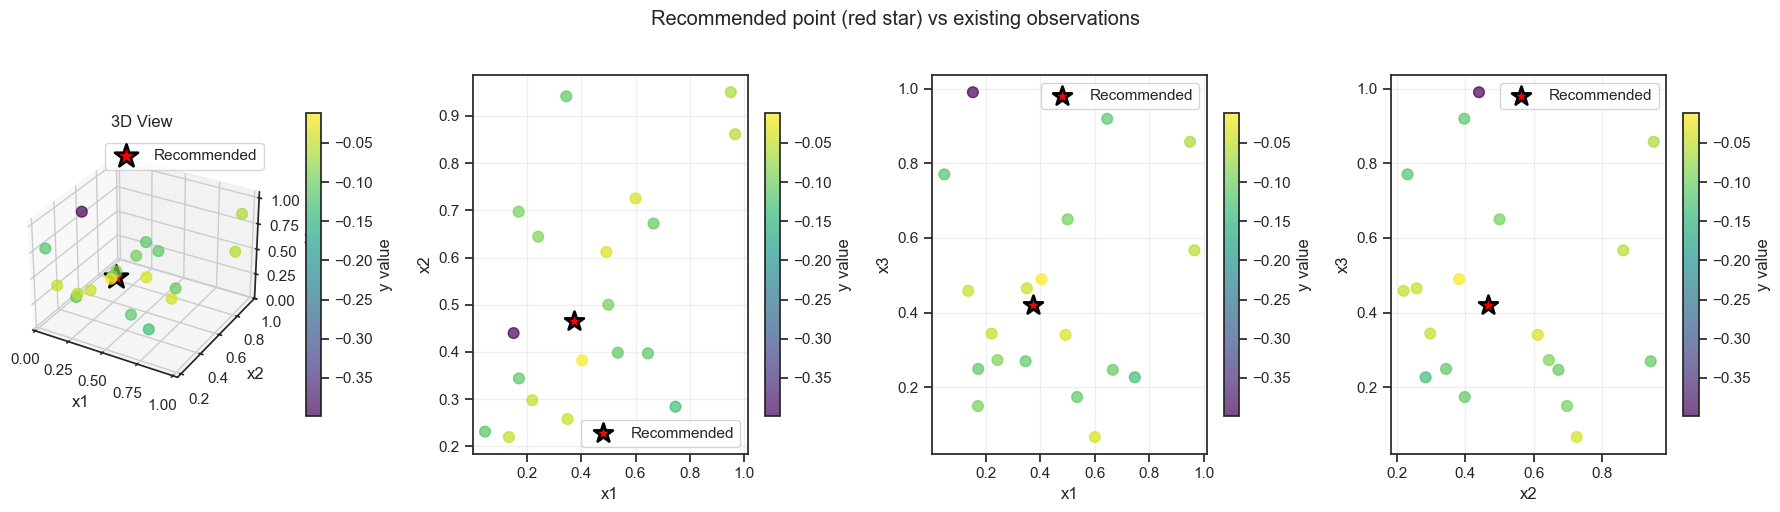

In [8]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


## Model parameter rationale (Week 5)
- Drug discovery often shows **activity cliffs** and meaningful **noise**, but the last exploratory jumps underperformed. We keep the smoother prior (**ν = 2.5**) and tightened length-scale/noise bounds to stay exploitative near the incumbent.
- EI uses a small **ξ = 0.001** to prioritise mean-driven gains while still valuing uncertainty.
- Current EI top set (feasible, min-step applied): `(0.373, 0.465, 0.419)` (mu ≈ −0.0117, σ ≈ 0.0398, EI ≈ 0.0154), then `(0.396, 0.465, 0.419)`, `(0.373, 0.465, 0.442)`, `(0.396, 0.488, 0.419)`, `(0.373, 0.488, 0.419)`.
- Recommended next query: **(0.373, 0.465, 0.419)** — it maximises EI by combining moderate variance with the best available mean in the shortlist while respecting the minimum-step rule. If this still stalls, consider switching to PI next.
